In [2]:
import pandas as pd
import numpy as np

# 1. Data Ingestion

In [3]:
df = pd.read_csv("/kaggle/input/datasets/mysarahmadbhat/lung-cancer/survey lung cancer.csv")

# 2. Data understandin and basic cleaning

In [105]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,Male,69,No,Yes,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,YES
1,Male,74,Yes,No,No,No,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,YES
2,Female,59,No,No,No,Yes,No,Yes,No,Yes,No,Yes,Yes,No,Yes,NO
3,Male,63,Yes,Yes,Yes,No,No,No,No,No,Yes,No,No,Yes,Yes,NO
4,Female,63,No,Yes,No,No,No,No,No,Yes,No,Yes,Yes,No,No,NO


In [5]:
df.shape

(309, 16)

In [6]:
df.duplicated().sum()

np.int64(33)

In [7]:
df = df.drop_duplicates()

In [8]:
df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [9]:
df.shape

(276, 16)

In [10]:
df.dtypes

GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL CONSUMING         int64
COUGHING                  int64
SHORTNESS OF BREATH       int64
SWALLOWING DIFFICULTY     int64
CHEST PAIN                int64
LUNG_CANCER              object
dtype: object

In [11]:
for col in df.select_dtypes(include=["object","int"]).columns:
    print(df[col].value_counts())
    print("")

GENDER
M    142
F    134
Name: count, dtype: int64

AGE
64    18
60    16
62    16
56    16
59    15
63    15
61    14
70    14
67    11
55    10
72    10
69    10
68     9
77     9
57     9
71     9
58     8
54     7
74     6
75     5
51     5
65     5
52     4
66     4
73     4
53     4
49     3
76     3
47     3
48     2
44     2
81     2
78     2
21     1
79     1
38     1
39     1
87     1
46     1
Name: count, dtype: int64

SMOKING
2    150
1    126
Name: count, dtype: int64

YELLOW_FINGERS
2    159
1    117
Name: count, dtype: int64

ANXIETY
1    139
2    137
Name: count, dtype: int64

PEER_PRESSURE
2    140
1    136
Name: count, dtype: int64

CHRONIC DISEASE
2    144
1    132
Name: count, dtype: int64

FATIGUE 
2    183
1     93
Name: count, dtype: int64

ALLERGY 
2    151
1    125
Name: count, dtype: int64

WHEEZING
2    151
1    125
Name: count, dtype: int64

ALCOHOL CONSUMING
2    152
1    124
Name: count, dtype: int64

COUGHING
2    159
1    117
Name: count, dtype: int64

S

In [12]:
df["GENDER"] = df["GENDER"].replace("M","Male")
df["GENDER"] = df["GENDER"].replace("F","Female")

df["SMOKING"] = df["SMOKING"].replace(1,"No")
df["SMOKING"] = df["SMOKING"].replace(2,"Yes")

df["YELLOW_FINGERS"] = df["YELLOW_FINGERS"].replace(1,"No")
df["YELLOW_FINGERS"] = df["YELLOW_FINGERS"].replace(2,"Yes")

df["ANXIETY"] = df["ANXIETY"].replace(1,"No")
df["ANXIETY"] = df["ANXIETY"].replace(2,"Yes")

df["PEER_PRESSURE"] = df["PEER_PRESSURE"].replace(1,"No")
df["PEER_PRESSURE"] = df["PEER_PRESSURE"].replace(2,"Yes")

df["CHRONIC DISEASE"] = df["CHRONIC DISEASE"].replace(1,"No")
df["CHRONIC DISEASE"] = df["CHRONIC DISEASE"].replace(2,"Yes")

df["FATIGUE "] = df["FATIGUE "].replace(1,"No")
df["FATIGUE "] = df["FATIGUE "].replace(2,"Yes")

df["ALLERGY "] = df["ALLERGY "].replace(1,"No")
df["ALLERGY "] = df["ALLERGY "].replace(2,"Yes")

df["WHEEZING"] = df["WHEEZING"].replace(1,"No")
df["WHEEZING"] = df["WHEEZING"].replace(2,"Yes")

df["ALCOHOL CONSUMING"] = df["ALCOHOL CONSUMING"].replace(1,"No")
df["ALCOHOL CONSUMING"] = df["ALCOHOL CONSUMING"].replace(2,"Yes")

df["COUGHING"] = df["COUGHING"].replace(1,"No")
df["COUGHING"] = df["COUGHING"].replace(2,"Yes")

df["SHORTNESS OF BREATH"] = df["SHORTNESS OF BREATH"].replace(1,"No")
df["SHORTNESS OF BREATH"] = df["SHORTNESS OF BREATH"].replace(2,"Yes")

df["SWALLOWING DIFFICULTY"] = df["SWALLOWING DIFFICULTY"].replace(1,"No")
df["SWALLOWING DIFFICULTY"] = df["SWALLOWING DIFFICULTY"].replace(2,"Yes")

df["CHEST PAIN"] = df["CHEST PAIN"].replace(1,"No")
df["CHEST PAIN"] = df["CHEST PAIN"].replace(2,"Yes")

In [13]:
df.describe()

,AGE
count,276.000000
mean,62.909420
std,8.379355
min,21.000000
25%,57.750000
50%,62.500000
75%,69.000000
max,87.000000


In [14]:
num_cols = df.select_dtypes(include=["int","float"]).columns
cat_cols = df.select_dtypes(include=["object"]).drop(columns=["LUNG_CANCER"]).columns
tar_col = "LUNG_CANCER"

# 3. Exploratory Data Analysis

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3.1. Univariate Analysis

**Num cols**

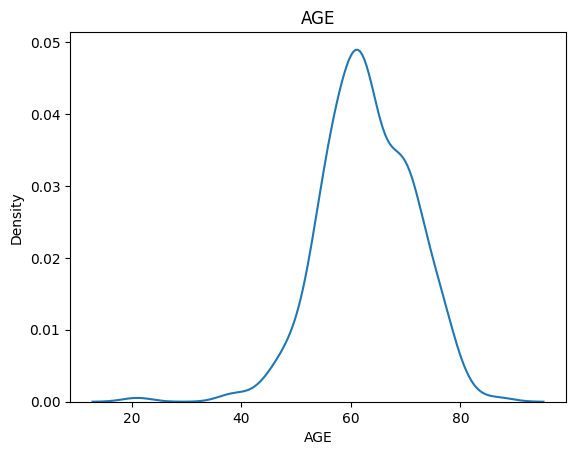

-0.45590088363012093


In [16]:
right_skew_cols = []
left_skew_cols = []
nrml_skew_cols = []
for col in num_cols:
    sns.kdeplot(x=col,data=df)
    plt.title(col)
    plt.show()
    print(df[col].skew())
    if df[col].skew() >= 0.5:
        right_skew_cols.append(col)
    elif df[col].skew() <= -0.5:
        left_skew_cols.append(col)
    else:
        nrml_skew_cols.append(col)

In [17]:
print(nrml_skew_cols)

['AGE']


**Cat cols**

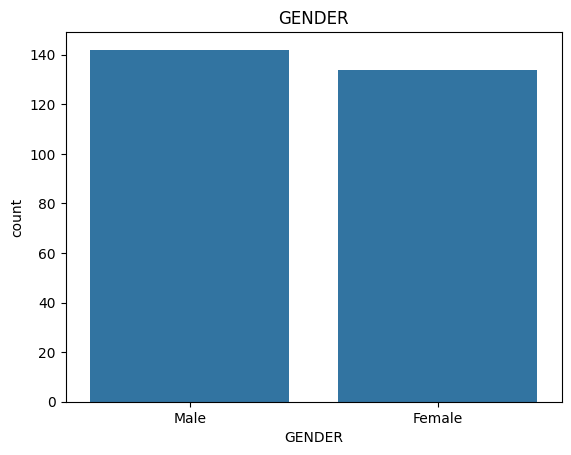

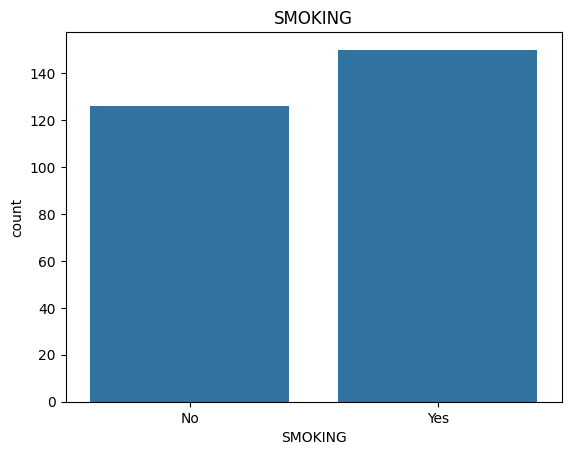

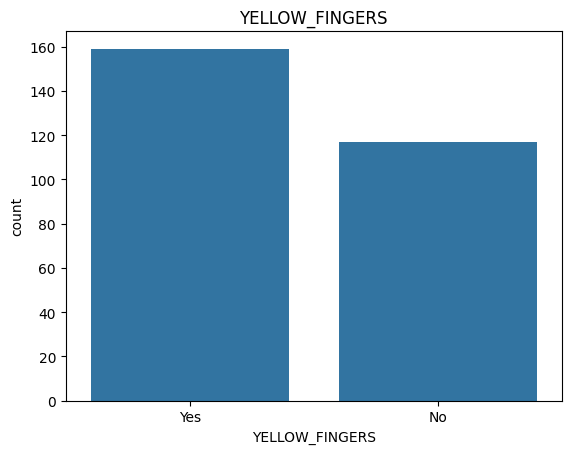

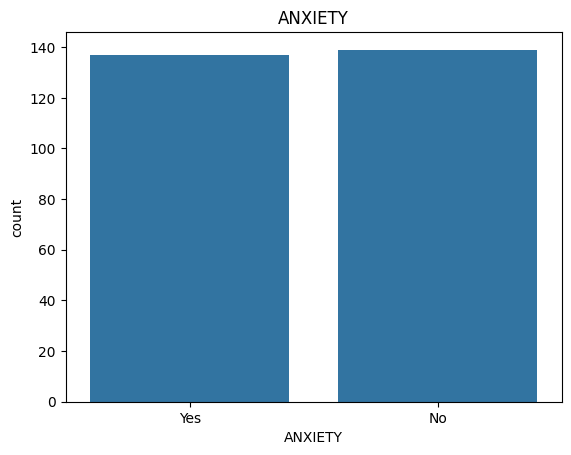

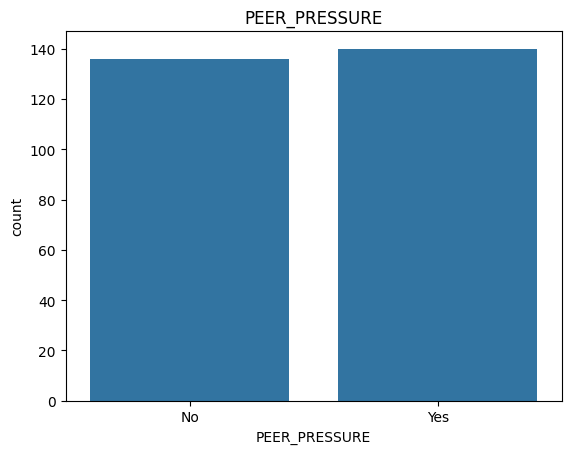

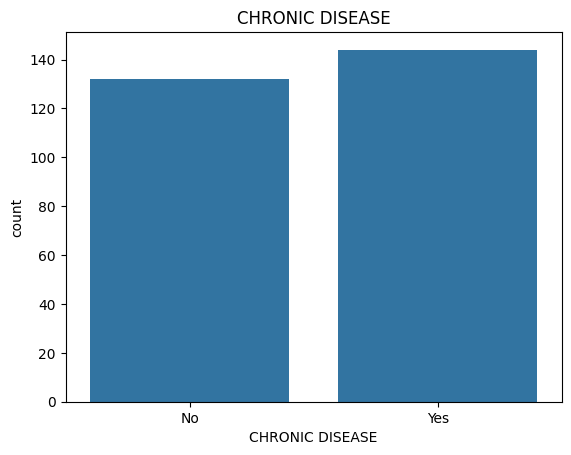

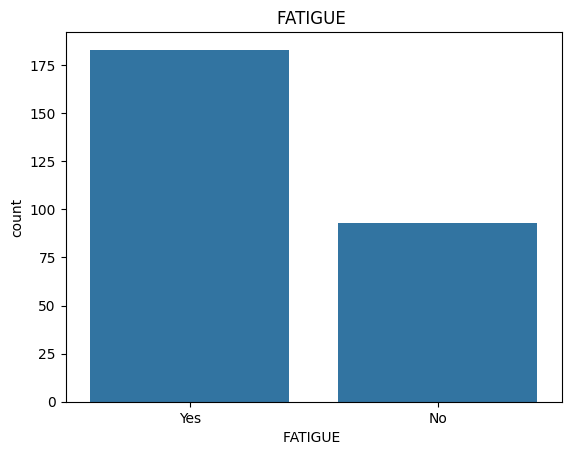

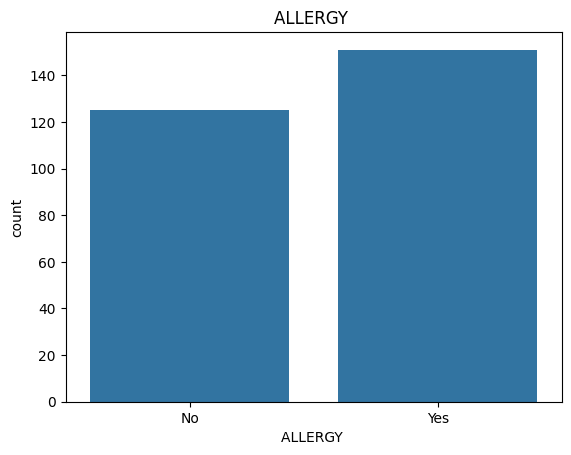

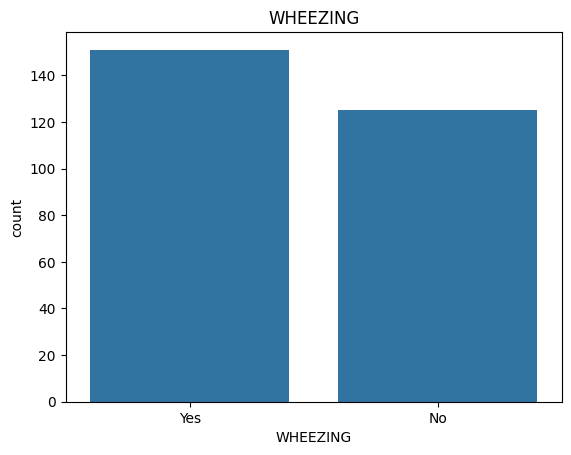

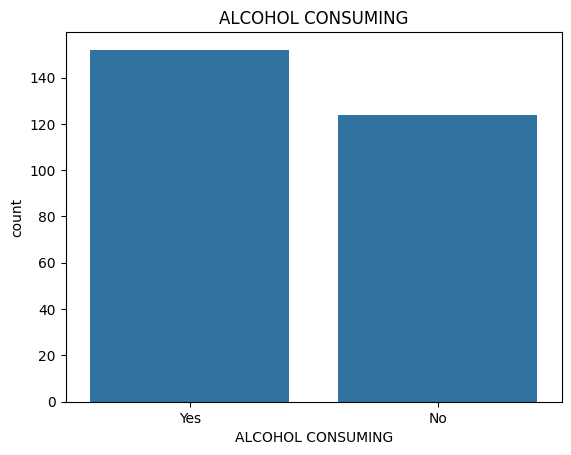

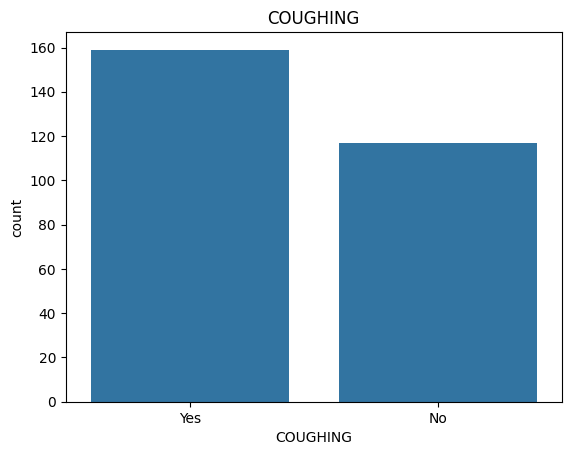

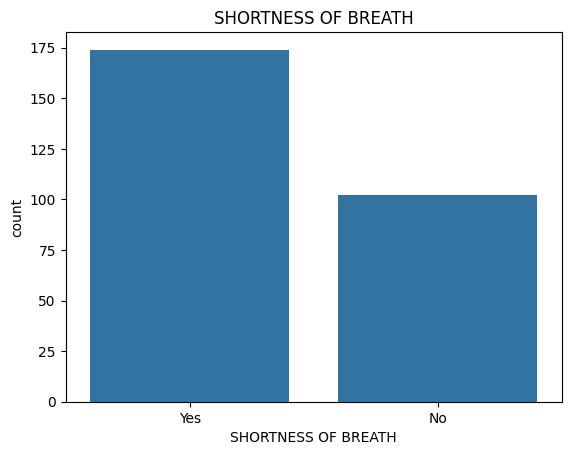

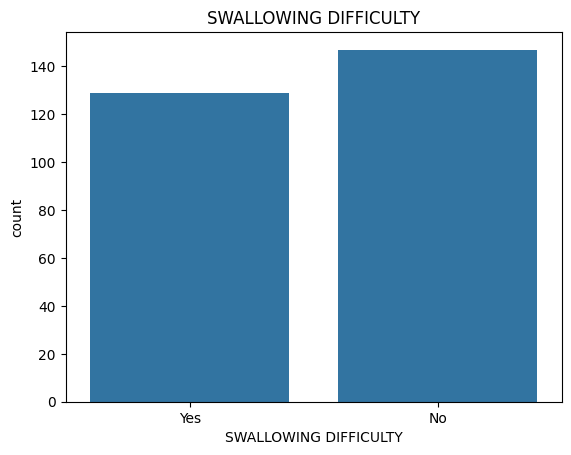

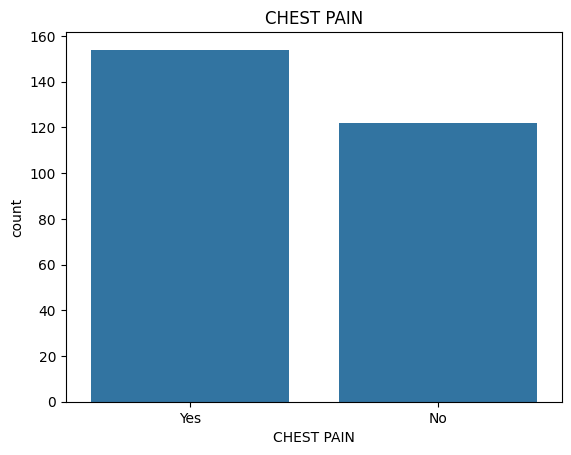

In [18]:
for col in cat_cols:
    sns.countplot(x=col,data=df)
    plt.title(col)
    plt.show()

* No much imbalance in every feature except FATIGUE & SHORTNESS OF BREATH

**Target col**

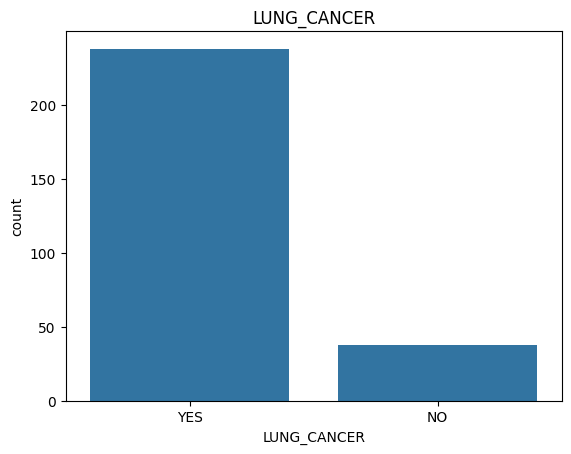

LUNG_CANCER
YES    238
NO      38
Name: count, dtype: int64

LUNG_CANCER
YES    0.862319
NO     0.137681
Name: proportion, dtype: float64


In [19]:
sns.countplot(x=tar_col,data=df)
plt.title(tar_col)
plt.show()
print(df[tar_col].value_counts())
print("")
print(df[tar_col].value_counts(normalize=True))

* ~72% of imbalanced data

# 3.2. Bivariate Analysis

**Num cols**

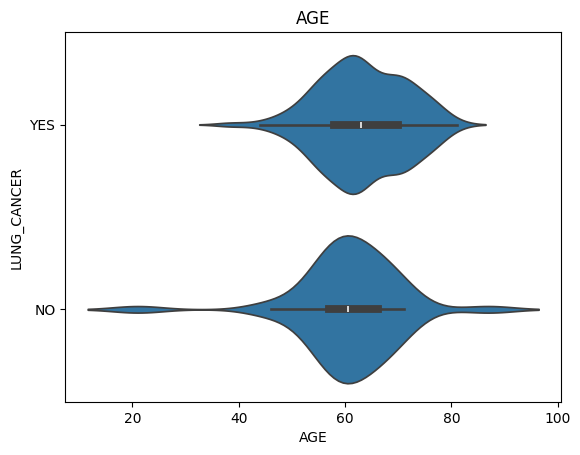

In [20]:
for col in num_cols:
    sns.violinplot(x=col,data=df,y=tar_col)
    plt.title(col)
    plt.show()

**Cat cols**

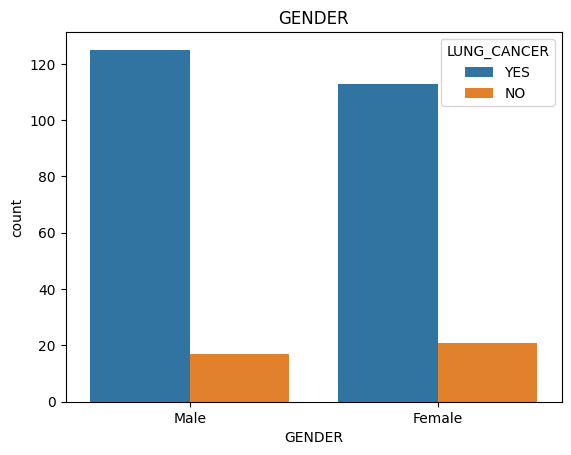

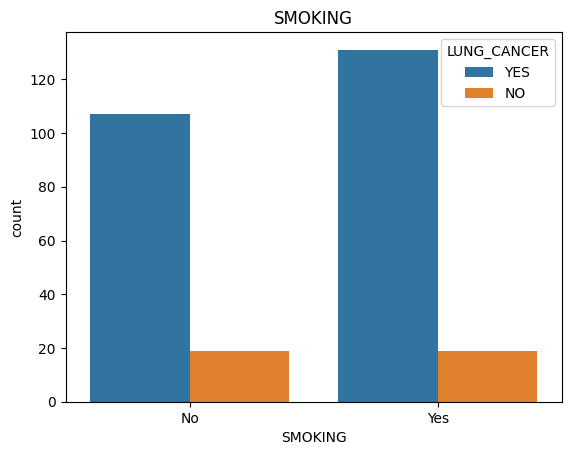

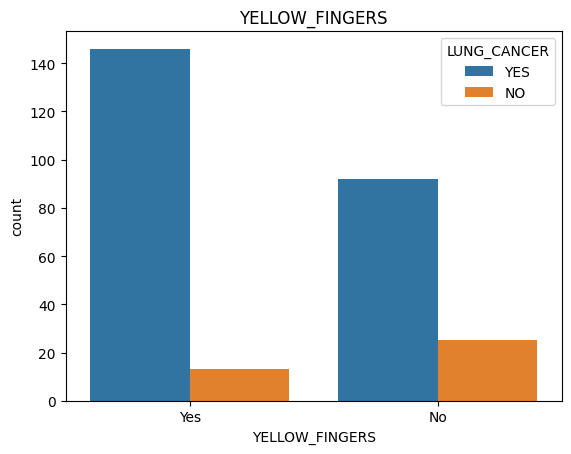

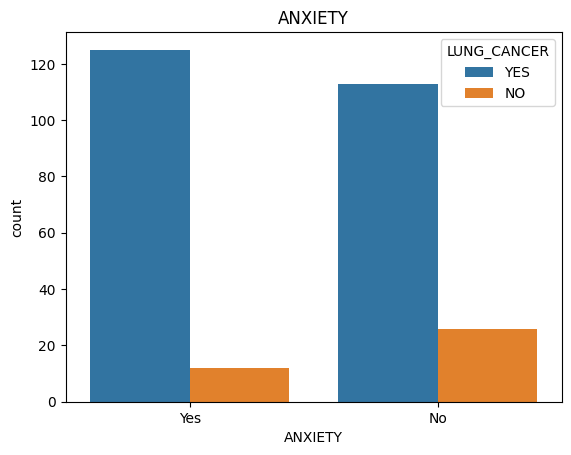

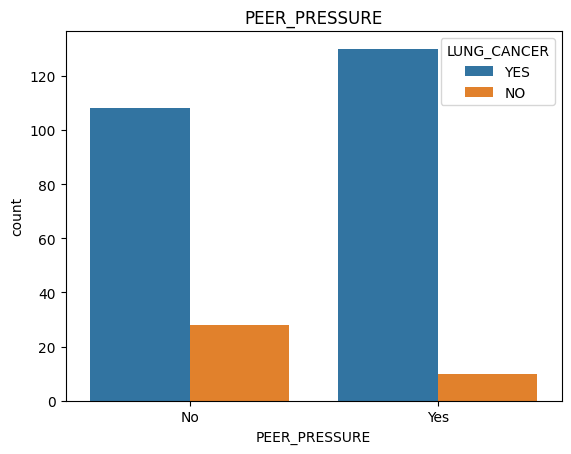

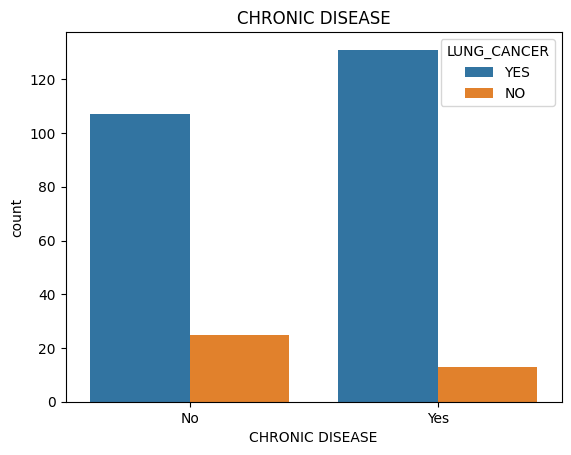

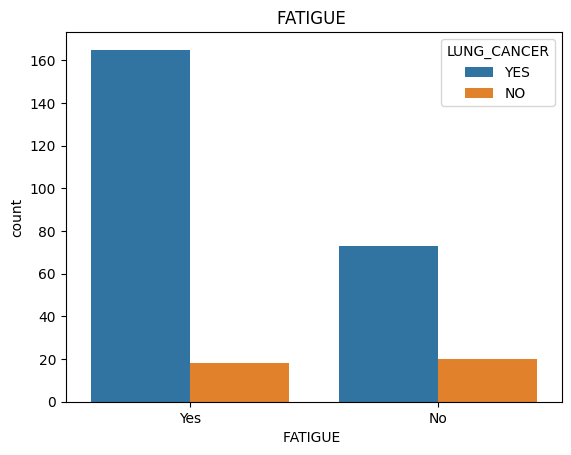

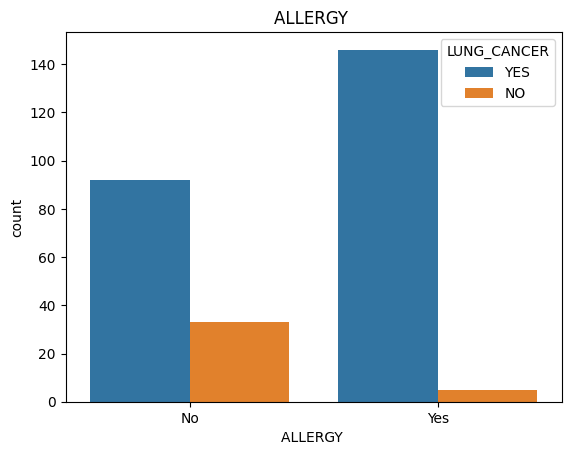

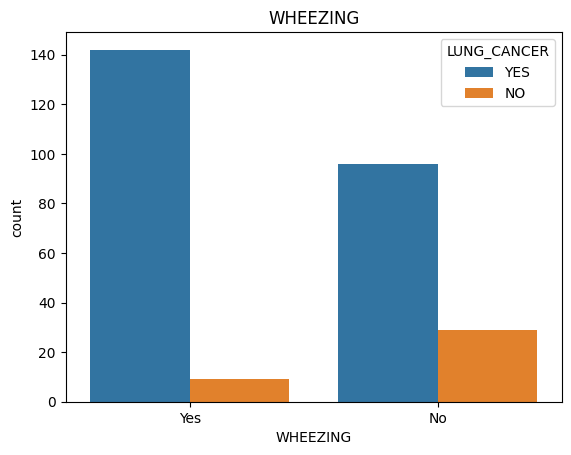

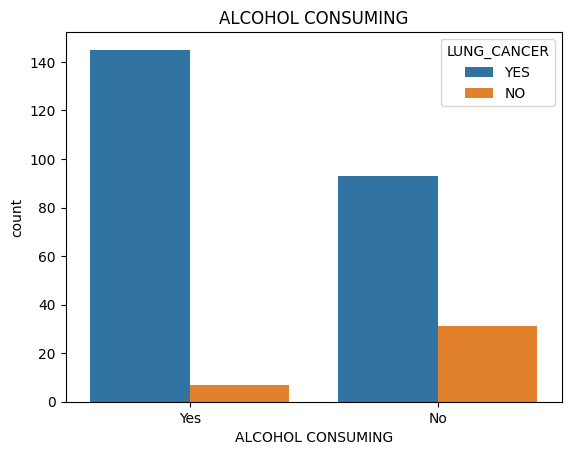

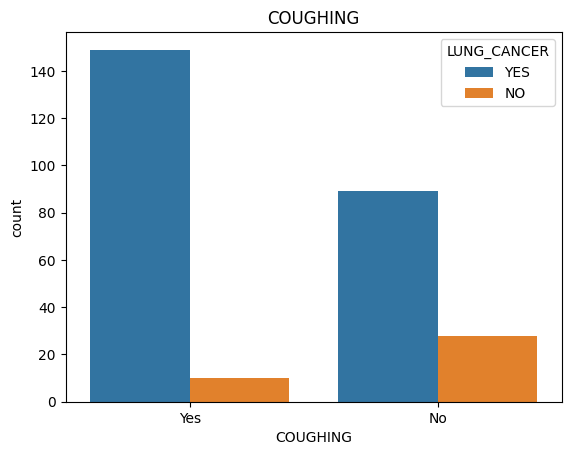

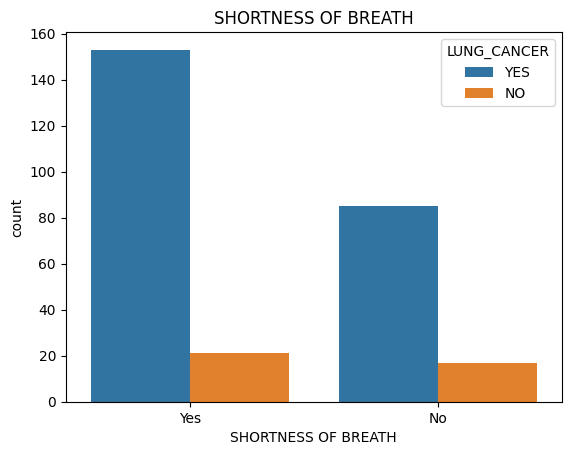

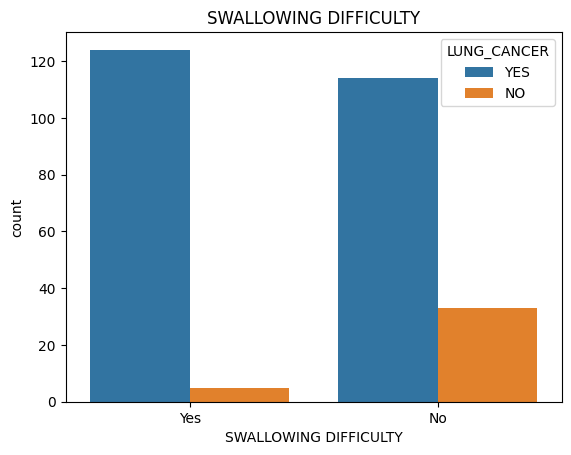

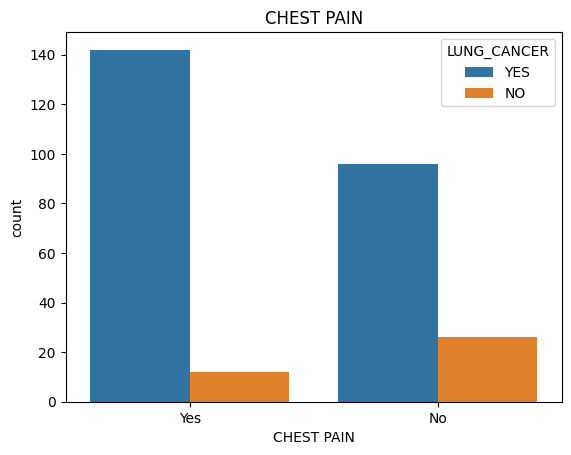

In [21]:
for col in cat_cols:
    sns.countplot(x=col,hue=tar_col,data=df)
    plt.title(col)
    plt.show()

# 4. Feature Engineering

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer,LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [23]:
df.sample()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
183,Female,71,Yes,No,No,No,Yes,Yes,No,No,No,No,Yes,No,No,NO


In [24]:
x = df.drop(columns=["LUNG_CANCER"])
y = df["LUNG_CANCER"]

# 4.1. Train-Test split

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

**sample data used in optuna function**

In [26]:
x_train,x_sample,y_train,y_sample = train_test_split(x_train,y_train,test_size=0.1,stratify=y_train)

# 4.2. Pipelines for each datatype

In [27]:
right_skew_pipeline = Pipeline(steps=[
    ("right_skew_transformer",PowerTransformer(method="yeo-johnson")),
    ("right_skew_scaler",StandardScaler())
])

In [28]:
left_skew_pipeline = Pipeline(steps=[
    ("left_skew_transformer",PowerTransformer(method="yeo-johnson")),
    ("left_skew_scaler",StandardScaler())
])

In [29]:
nrml_skew_pipeline = Pipeline(steps=[
    ("nrml_skew_scler",StandardScaler())
])

In [30]:
cat_pipeline = Pipeline(steps=[
    ("OHEncoder",OneHotEncoder(handle_unknown="ignore"))
])

# 4.3. Combining all pipelines

In [31]:
preprocessor = ColumnTransformer(transformers=[
    ("nrml_skew_pipeline",nrml_skew_pipeline,nrml_skew_cols),
    ("cat_pipeline",cat_pipeline,cat_cols)
])

# 4.4. Encoding Target values (LabelEncoder)

In [32]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
y_sample = le.transform(y_sample)

# 5. Model selection & hyperparameter tuining (Optuna)

In [33]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [54]:
def objective(trial):
    model_name = trial.suggest_categorical("model", ["lr", "dt", "rf", "xgb"])

    if model_name == "lr":
        model = LogisticRegression(
        C=trial.suggest_float("C", 1e-3, 10, log=True),
        solver=trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
        max_iter=1000
    )

    elif model_name == "dt":
        model = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 3, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"])
    )

    elif model_name == "rf":
        model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        n_jobs=-1
    )

    elif model_name == "xgb":
        model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        reg_alpha=trial.suggest_float("reg_alpha", 0, 5),
        reg_lambda=trial.suggest_float("reg_lambda", 0, 5),
        use_label_encoder=False,
        eval_metric="logloss",
        n_jobs=-1,
        verbosity=0
    )
    tuner_pipeline = Pipeline(steps=[
        ("preprocessor",preprocessor),
        ("SMOTE",SMOTE(random_state=42,k_neighbors=1)),
        ("model",model)
    ])
    tuner_score = cross_val_score(tuner_pipeline,x_train,y_train,cv=3,scoring="f1")
    return tuner_score.mean()

In [55]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=100)

[I 2026-08-18 12:43:45,394] A new study created in memory with name: no-name-4a65517d-f3db-4a56-87ce-54b7ef93fe61
[I 2026-08-18 12:43:45,505] Trial 0 finished with value: 0.9277641277641276 and parameters: {'model': 'lr', 'C': 0.09770693353178682, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9277641277641276.
[I 2026-08-18 12:43:48,750] Trial 1 finished with value: 0.9187806007027975 and parameters: {'model': 'rf', 'n_estimators': 366, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.9277641277641276.
[I 2026-08-18 12:43:48,935] Trial 2 finished with value: 0.9318820700399648 and parameters: {'model': 'lr', 'C': 2.9447209910199525, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.9318820700399648.
[I 2026-08-18 12:43:49,061] Trial 3 finished with value: 0.8742562334262584 and parameters: {'model': 'dt', 'max_depth': 20, 'min_samples_split': 17, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 2 w

In [56]:
params = study.best_params
params

{'model': 'rf',
 'n_estimators': 105,
 'max_depth': 30,
 'min_samples_split': 2,
 'min_samples_leaf': 9,
 'max_features': 'log2'}

In [57]:
model_name = params["model"]

if model_name == "lr":
    final_model = LogisticRegression(
        C=params["C"],
        solver=params["solver"],
        max_iter=1000
    )

elif model_name == "dt":
    final_model = DecisionTreeClassifier(
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        criterion=params["criterion"]
    )

elif model_name == "rf":
    final_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        n_jobs=-1
    )

elif model_name == "xgb":
    final_model = XGBClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],
        use_label_encoder=False,
        eval_metric="logloss",
        n_jobs=-1,
        verbosity=0
    )


# 6. final_pipeline (preprocessor + SMOTE + best model with best params)

In [58]:
final_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("SMOTE",SMOTE(random_state=42,k_neighbors=1)),
    ("final_model",final_model)
])

# 6.1. Score of final_pipeline 

In [59]:
scores = cross_val_score(final_pipeline,x_train,y_train,cv=3,scoring="f1")
print(f"Scores: {scores}")
print(f"Scores mean: {scores.mean()}")

Scores: [0.95652174 0.89655172 0.9380531 ]
Scores mean: 0.9303755202044995


# 7. Training the model

In [60]:
final_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nrml_skew_pipeline',
                                                  Pipeline(steps=[('nrml_skew_scler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('OHEncoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['GENDER', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
       'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN'],
      dtype='object'))])),
                ('SMOTE', SMOTE(k_neighbors=1, random_state=42)),
                ('final_model',
                 RandomForestClassifier(max_depth=30, max_features='log2',
                                        min_samples_leaf=9, n_estimators=105,
                                        n_jobs=-1))])

# 8. Prediction

In [61]:
train_pred = final_pipeline.predict(x_train)
test_pred = final_pipeline.predict(x_test)

# 9. Model Evaluation

In [62]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

# 9.1. Accuracy score

In [63]:
train_acc = accuracy_score(y_train,train_pred)
print(f"Train Acc: {train_acc}")
test_acc = accuracy_score(y_test,test_pred)
print(f"Test Acc: {test_acc}")

Train Acc: 0.9242424242424242
Test Acc: 0.9464285714285714


# 9.2. Precision score

In [64]:
train_precision = precision_score(y_train,train_pred)
print(f"Train precision: {train_precision}")
test_precision = precision_score(y_test,test_pred)
print(f"Test precision: {test_precision}")

Train precision: 0.975609756097561
Test precision: 0.9591836734693877


# 9.3. Recall score

In [65]:
train_recall = recall_score(y_train,train_pred)
print(f"Train recall: {train_recall}")
test_recall = recall_score(y_test,test_pred)
print(f"Test recall: {test_recall}")

Train recall: 0.935672514619883
Test recall: 0.9791666666666666


# 9.4. f1 score

In [66]:
train_f1 = f1_score(y_train,train_pred)
print(f"Train f1: {train_f1}")
test_f1 = f1_score(y_test,test_pred)
print(f"Test f1: {test_f1}")

Train f1: 0.9552238805970149
Test f1: 0.9690721649484536


# 9.5. Confusion matrix

Train CM: 
[[ 23   4]
 [ 11 160]]


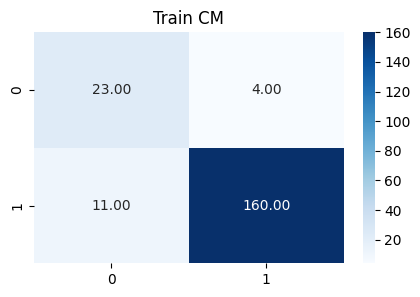



Test CM: 
[[ 6  2]
 [ 1 47]]


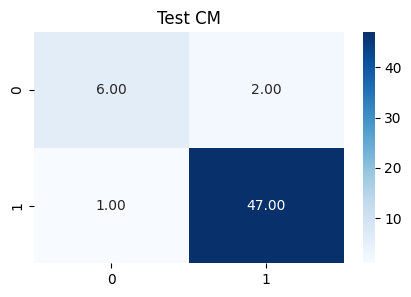

In [67]:
train_cm = confusion_matrix(y_train,train_pred)
print(f"Train CM: \n{train_cm}")
plt.figure(figsize=(5,3))
sns.heatmap(train_cm,annot=True,fmt=".2f",cmap="Blues")
plt.title("Train CM")
plt.show()

test_cm = confusion_matrix(y_test,test_pred)
print(f"\n\nTest CM: \n{test_cm}")
plt.figure(figsize=(5,3))
sns.heatmap(test_cm,annot=True,fmt=".2f",cmap="Blues")
plt.title("Test CM")
plt.show()

# 9.6. Classification report

In [68]:
train_cr = classification_report(y_train,train_pred)
print(f"Train CR: \n{train_cr}")

test_cr = classification_report(y_test,test_pred)
print(f"\n\nTest CR: \n{test_cr}")

Train CR: 
              precision    recall  f1-score   support

           0       0.68      0.85      0.75        27
           1       0.98      0.94      0.96       171

    accuracy                           0.92       198
   macro avg       0.83      0.89      0.85       198
weighted avg       0.93      0.92      0.93       198



Test CR: 
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.96      0.98      0.97        48

    accuracy                           0.95        56
   macro avg       0.91      0.86      0.88        56
weighted avg       0.94      0.95      0.94        56



# 10. Model Explainability(Shap)

In [77]:
import shap

In [78]:
shap_preprocessor = final_pipeline.named_steps["preprocessor"]
shap_model = final_pipeline.named_steps["final_model"]

In [79]:
feature_names = []
for col in shap_preprocessor.get_feature_names_out():
    feature_names.append(col.split("__")[-1])

In [80]:
x_test_t = pd.DataFrame(
    shap_preprocessor.transform(x_test),
    columns=feature_names
)

In [81]:
explainer = shap.Explainer(shap_model)

In [82]:
shap_values = explainer(x_test_t)

In [93]:
shap_values.shape

(56, 29, 2)

# 10.1. Importance/Bar plot

NO


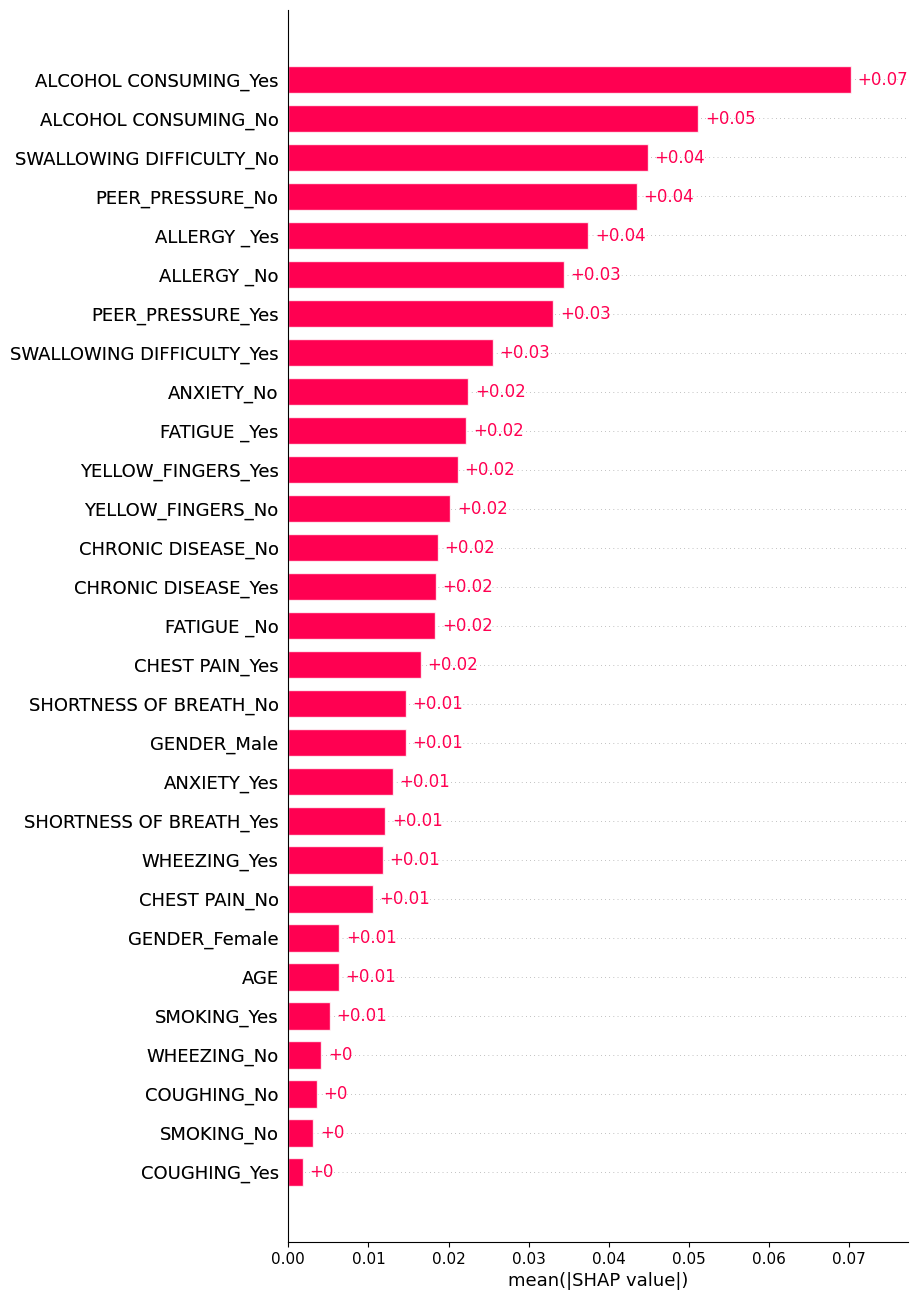

YES


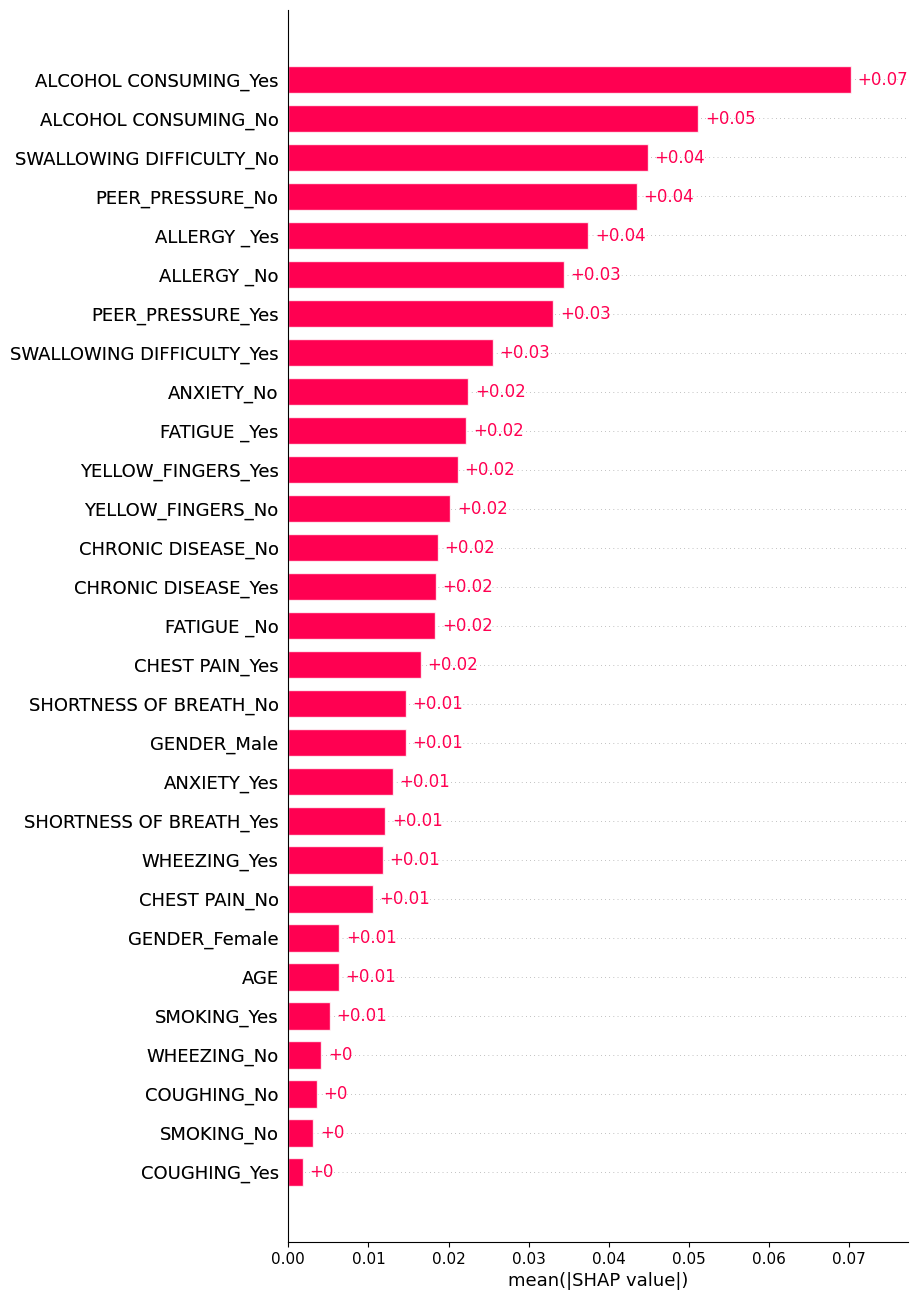

In [98]:
for category in range(len(le.classes_)):
    print(le.classes_[category])
    shap.plots.bar(shap_values[:,:,category],max_display=len(feature_names))

# 10.2. Beeswarm plot

NO


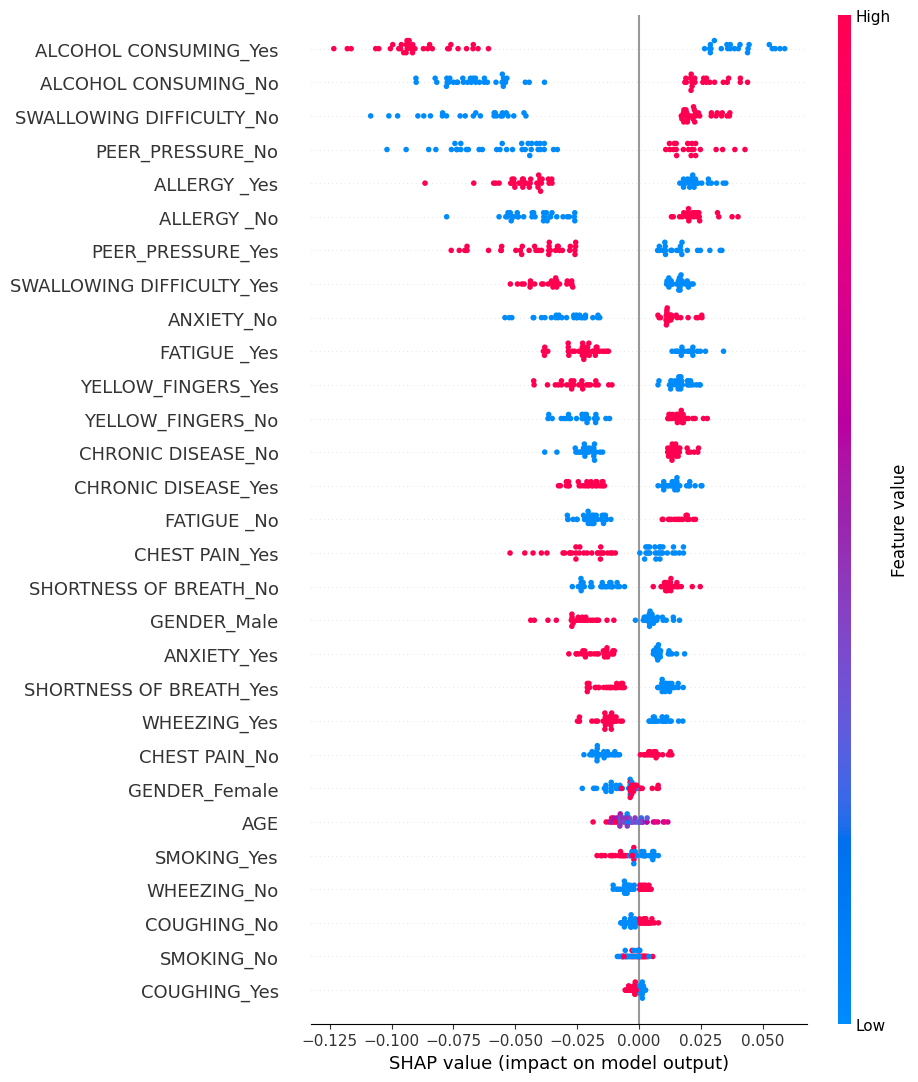

YES


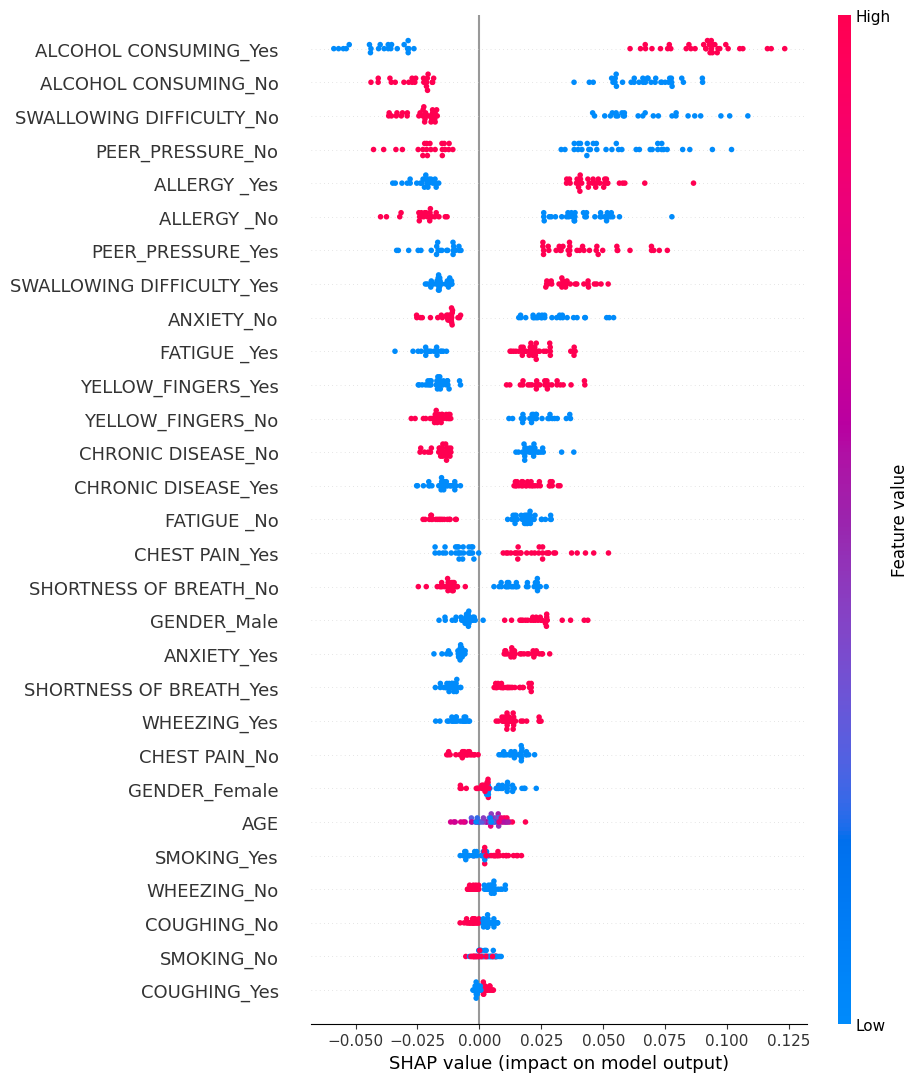

In [99]:
for category in range(len(le.classes_)):
    print(le.classes_[category])
    shap.plots.beeswarm(shap_values[:,:,category],max_display=len(feature_names))

# 11. Model Explainability(mlflow)

In [102]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 85.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 11.1 MB/s eta 0:00:00


In [103]:
import mlflow

In [104]:
mlflow.set_experiment("Lung_Cancer_Detection")
with mlflow.start_run(run_name="RFC_SMOTE_V1"):
    mlflow.log_params(params)

    mlflow.log_metric("Train Acc",train_acc)
    mlflow.log_metric("Test Acc",test_acc)
    mlflow.log_metric("Train precision",train_precision)
    mlflow.log_metric("Test precision",test_precision)
    mlflow.log_metric("Train recall",train_recall)
    mlflow.log_metric("Test recall",test_recall)
    mlflow.log_metric("Train f1",train_f1)
    mlflow.log_metric("Test f1",test_f1)

    mlflow.sklearn.log_model(final_pipeline,"final_pipeline",serialization_format="cloudpickle",registered_model_name="Lung_Cancer_Classifier")

2026/08/18 13:07:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/18 13:07:14 INFO mlflow.store.db.utils: Updating database tables
2026/08/18 13:07:18 INFO mlflow.tracking.fluent: Experiment with name 'Lung_Cancer_Detection' does not exist. Creating a new experiment.
2026/08/18 13:07:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/18 13:07:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Lung_Cancer_Classifier'.
Created version '1' of model 'Lung_Cancer_Classifier'.


In [106]:
best_registry_model = mlflow.sklearn.load_model("models:/Lung_Cancer_Classifier/1")
mlflow.sklearn.save_model(best_registry_model,"best_registry_model",serialization_format="cloudpickle")

2026/08/18 13:35:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
